In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = t=utils.load_data_universal("db/results.sqlite")


df.keys()

Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)


Index(['result_id', 'question_id_external', 'question_text', 'gold_answer',
       'predicted_answer', 'full_trace_text', 'is_correct', 'Entropy',
       'LogitGap', 'Heuristic', 'Mechanistic', 'Semantic', 'Reason',
       'Consistency', 'similarity_vector', 'uq_tokens', 'uq_mech_trace',
       'uq_entropy_trace', 'uq_logit_gap_trace', 'Correct', 'Length',
       'Entropy_Z', 'LogitGap_Z', 'Heuristic_Z', 'Mechanistic_Z',
       'Consistency_Z', 'Semantic_Z', 'Length_Z'],
      dtype='object')

In [2]:
# Recover the tree answer (as extracted by the LLM judge) since predicted answer was inaccurate
df['int_from_reason'] = df['Reason'].astype(str).str.extract(r'(\d+)')

df['int_from_pred'] = df['predicted_answer'].astype(str).str.extract(r'(\d+)')

df['final_int_str'] = df['int_from_reason'].fillna(df['int_from_pred'])

df['Answer_Int'] = pd.to_numeric(df['final_int_str'], errors='coerce').fillna(-1).astype(int)

total = len(df)
recovered_reason = df['int_from_reason'].notna().sum()
recovered_fallback = (df['int_from_reason'].isna() & df['final_int_str'].notna()).sum()
failed = (df['Answer_Int'] == -1).sum()

print(f"Total Rows: {total}")
print(f"Extracted from Reason:     {recovered_reason} ({recovered_reason/total:.1%})")
print(f"Recovered from Fallback:   {recovered_fallback} ({recovered_fallback/total:.1%})")
print(f"Failed (No Int found):     {failed} ({failed/total:.1%})")

# Preview the "Saved" rows
if recovered_fallback > 0:
    print("\nSample of rows saved by fallback:")
    display(df[df['int_from_reason'].isna() & df['final_int_str'].notna()]
            [['Reason', 'predicted_answer', 'Answer_Int']].head())

Total Rows: 3874
Extracted from Reason:     3866 (99.8%)
Recovered from Fallback:   8 (0.2%)
Failed (No Int found):     0 (0.0%)

Sample of rows saved by fallback:


,Reason,predicted_answer,Answer_Int
1050,Extracted: infty,0,0
1213,Extraction Failed (No JSON returned),50,50
1895,Extraction Failed (No JSON returned),145,145
2369,Extraction Failed (No JSON returned),2,2
2665,Extraction Failed (No JSON returned),125,125


In [3]:
def calc_se_hybrid(sub):
    # Filter out failures (-1) so they don't artificially inflate entropy
    valid_answers = sub[sub['Answer_Int'] != -1]['Answer_Int']
    
    if len(valid_answers) == 0:
        return 0.0
        
    probs = valid_answers.value_counts(normalize=True)
    return -np.sum(probs * np.log(probs + 1e-10))

if 'question_id_external' in df.columns:
    se_map = df.groupby('question_id_external').apply(calc_se_hybrid)
    df['Semantic'] = df['question_id_external'].map(se_map)
    
        
    print("Semantic Entropy updated using Extraction.")

Semantic Entropy updated using Extraction.


/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_95897/4234720691.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  se_map = df.groupby('question_id_external').apply(calc_se_hybrid)


In [4]:
import sqlite3

def update_database(df, db_path="db/results.sqlite"):
    print(f"Connecting to {db_path}...")
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    try:
        cursor.execute("ALTER TABLE Results ADD COLUMN uq_cleaned_answer INTEGER")
        print("Created new column: 'uq_cleaned_answer'")
    except sqlite3.OperationalError:
        pass

    update_data = df[['Semantic', 'Answer_Int', 'result_id']].values.tolist()
    
    print(f"Updating {len(update_data)} rows.")
    
    query = """
    UPDATE Results 
    SET 
        uq_semantic_entropy = ?,
        uq_cleaned_answer = ?
    WHERE result_id = ?
    """
    
    try:
        cursor.executemany(query, update_data)
        conn.commit()
        print(f"Successfully updated {cursor.rowcount} rows.")
    except Exception as e:
        print(f"Update failed: {e}")
        conn.rollback()
    finally:
        conn.close()

# Run The Update
if 'Answer_Int' in df.columns and 'Semantic' in df.columns:
    update_database(df)
else:
    print("DataFrame missing 'Answer_Int' or 'Semantic' columns. Run the calculation step first.")

Connecting to db/results.sqlite...
Updating 3874 rows.
Successfully updated 3874 rows.


(array([2588.,    0.,    0.,    0.,  712.,  102.,    0.,  352.,    0.,
         120.]),
 array([-1.00000008e-10,  1.38629436e-01,  2.77258872e-01,  4.15888308e-01,
         5.54517744e-01,  6.93147180e-01,  8.31776616e-01,  9.70406052e-01,
         1.10903549e+00,  1.24766492e+00,  1.38629436e+00]),
 <BarContainer object of 10 artists>)

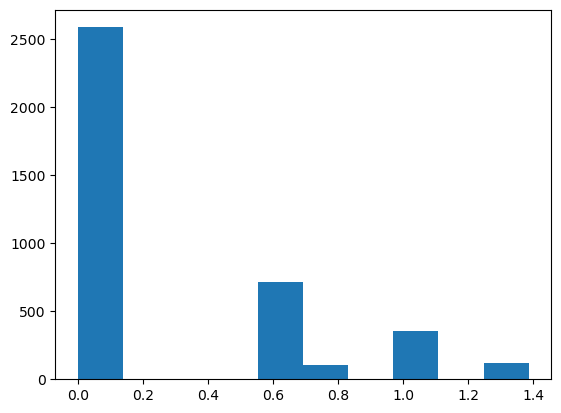

In [5]:
plt.hist(df["Semantic"])